# NB104: The Four Waves — How the Cascade Creates Mass

**Goal**: Understand how each cascade level's wave character contributes to
fermion mass ratios. Not identity-hunting — mechanism-understanding.

**The mass architecture** (from NB70–81):

| Mass Ratio | Formula | Levels Used | Level Characters |
|-----------|---------|-------------|-----------------|
| m_s/m_d | R₄^{x₄} | Level 3 only | Overdamped (Q≈0.43) |
| m_μ/m_e | R₄^{x₄_lep} | Level 3 only | Overdamped (Q≈0.43) |
| m_c/m_u | R₃^{x₃} · R₄^{x₄} | Levels 2 + 3 | Near-critical + overdamped |
| m_b/m_s | R₂^{x₂} | Level 1 only | Underdamped (Q≈15.2) |
| m_t/m_c | R₂^{x₂} · R₃^{x₃} / R₄^{λ₇} | Levels 1 + 2 + 3 | All three mass-active levels |

Level 0 (p=2, Q≈45.5) enters **no** mass formula.

**Questions**:
1. What does each level's wave look like?
2. Does the universal transient decomposition R_k = R_k_ss + 2π·j_{k+1}·exp(−κ·ci) hold at ALL levels?
3. How does wrapping work at each level?
4. How do the CP ratios arise from each level's character?
5. Why are the exponents {7.64, 1.91, 1.27} paired with the levels they are?

In [1]:
# ── S0: Setup + Integration + Reference ──
import sys, numpy as np, time, matplotlib.pyplot as plt
from pathlib import Path
from math import gcd

ROOT = Path.cwd().parent
if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))

from solenoid_algebra import (SA, RHO, KAPPA, OMEGA, PRIMES, P, PHI,
    X4, X3, X2, LAM7, X4_LEP, DLOG, PHYSICAL_CROSSINGS,
    CP_PAIRS, SM_TARGETS, PRIMORIALS)
from solenoid_system import SolenoidSystem
from solenoid_jax import integrate_all_branches_jax, warmup

T_MAX = 5001
ss = SolenoidSystem()
branches = ss.all_branches()

# Coprime crossings and CRT labels
coprime_cis = SA.coprime_indices(T_MAX)
ci_a3, ci_a5, ci_a7 = SA.sector_labels(coprime_cis)
t_eval = coprime_cis.astype(float) + 1.0

# Integrate with JAX
warmup()
t0 = time.time()
results = integrate_all_branches_jax(branches, t_eval, float(T_MAX) + 1.0)
dt = time.time() - t0

# Reference mass predictions
sector_rms = SolenoidSystem.accumulate_sectors(
    results, coprime_cis, ci_a3, ci_a5, ci_a7)
cp_ratios = SolenoidSystem.cp_pair_ratios(sector_rms)
mass_preds = SA.mass_ratios(cp_ratios)

print(f"NB104: The Four Waves")
print(f"  {len(branches)} branches, T={T_MAX}, {len(coprime_cis)} crossings")
print(f"  Integration: {dt:.1f}s (JAX)")
print(f"\nCP ratios [R₁(p=2), R₂(p=3), R₃(p=5), R₄(p=7)]:")
for ch, r in cp_ratios.items():
    print(f"  {ch}: [{', '.join(f'{v:.4f}' for v in r)}]")

print(f"\nMass predictions vs PDG:")
print(f"  {'Ratio':<12} {'Pred':>8} {'PDG':>8} {'Dev%':>7}")
print(f"  {'-'*37}")
for name, pred in mass_preds.items():
    tgt, unc = SM_TARGETS[name]
    dev = (pred - tgt) / tgt * 100
    print(f"  {name:<12} {pred:>8.2f} {tgt:>8.2f} {dev:>+7.1f}%")

print(f"\nExponents: X₄={X4:.4f}, X₃={X3:.4f}, X₂={X2:.4f}, λ₇={LAM7}")
print(f"           X₄_lep={X4_LEP:.4f}")
print(f"κ = ε = 1/√210 = {KAPPA:.6f}")

  JAX [CPU (1 device(s))]: 210 branches, 1143 eval pts, T=5002.0 — 12.07s
NB104: The Four Waves
  210 branches, T=5001, 1143 crossings
  Integration: 12.1s (JAX)

CP ratios [R₁(p=2), R₂(p=3), R₃(p=5), R₄(p=7)]:
  QUARK: [36.0133, 19.8402, 6.1719, 1.5388]
  LEPTON: [6.3908, 5.8156, 4.2644, 1.9422]

Mass predictions vs PDG:
  Ratio            Pred      PDG    Dev%
  -------------------------------------
  m_s/m_d         26.92    20.00   +34.6%
  m_c/m_u        870.18   588.00   +48.0%
  m_b/m_s         44.88    44.75    +0.3%
  m_t/m_c        109.28   135.80   -19.5%
  m_mu/m_e       177.11   206.77   -14.3%

Exponents: X₄=7.6394, X₃=1.9099, X₂=1.2732, λ₇=6
           X₄_lep=7.7986
κ = ε = 1/√210 = 0.069007


## S1: The Four Wave Characters

Each cascade level is a first-order damped system `dR_k/dt = f_k(t) − κ·R_k` driven
by the level above it. The Q-factor hierarchy {45.5, 15.2, 3.0, 0.43} creates four
fundamentally different wave characters:

- **Level 0** (p=2, Q≈45.5): wildly oscillatory — steady state dominated by sin(ωt) forcing
- **Level 1** (p=3, Q≈15.2): moderately oscillatory — filtered version of Level 0
- **Level 2** (p=5, Q≈3.0): near-critical — few oscillations, approaching monotonic
- **Level 3** (p=7, Q≈0.43): overdamped — pure exponential decay, smooth steady state

Visualize all four levels for a high-activity branch to see the hierarchy.

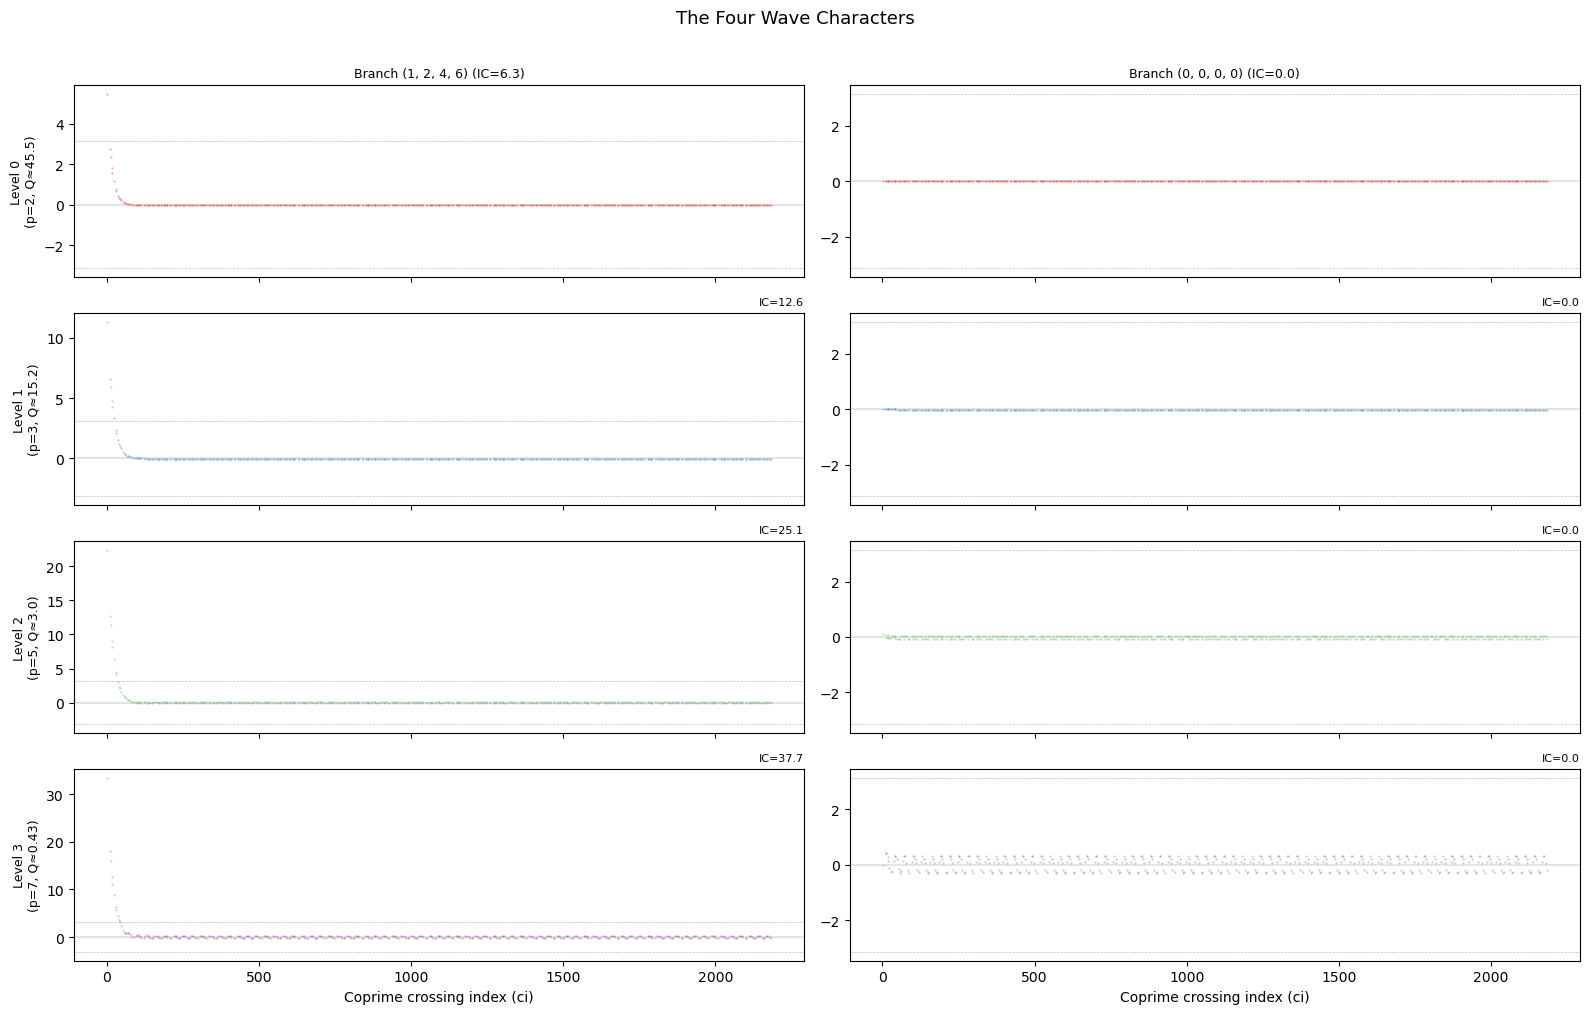


Wave statistics across all 210 branches:
 Level  Prime     IC range     Max|R|   Mean RMS   Wraps%
--------------------------------------------------------------
  R_ 0   p= 2  [0,   6.28]        5.47     0.1510      0.0%
  R_ 1   p= 3  [0,  12.57]       11.33     0.3042      0.2%
  R_ 2   p= 5  [0,  25.13]       22.37     0.5687      0.4%
  R_ 3   p= 7  [0,  37.70]       33.41     0.8397      0.5%


In [2]:
# ── S1: The Four Wave Characters ──
# Pick a high-activity branch: large ICs at all levels
br_high = (1, 2, 4, 6)  # j1=1, j2=2, j3=4, j4=6
R_high = results[br_high]  # (n_coprime, 4)

# Also show a "quiet" branch for contrast
br_quiet = (0, 0, 0, 0)
R_quiet = results[br_quiet]

# Show first 500 crossings (~2.5 primorial windows)
n_show = 500
cis_show = coprime_cis[:n_show]

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex='col')
level_names = ['Level 0\n(p=2, Q≈45.5)',
               'Level 1\n(p=3, Q≈15.2)',
               'Level 2\n(p=5, Q≈3.0)',
               'Level 3\n(p=7, Q≈0.43)']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for k in range(4):
    for col, (br, R_br, label) in enumerate([
        (br_high, R_high, f'Branch {br_high}'),
        (br_quiet, R_quiet, f'Branch {br_quiet}')
    ]):
        ax = axes[k, col]
        ax.plot(cis_show, R_br[:n_show, k], '.', ms=0.8,
                color=colors[k], alpha=0.5)
        ax.axhline(np.pi, color='gray', ls='--', lw=0.5, alpha=0.5)
        ax.axhline(-np.pi, color='gray', ls='--', lw=0.5, alpha=0.5)
        ax.axhline(0, color='gray', ls='-', lw=0.3)
        if col == 0:
            ax.set_ylabel(level_names[k], fontsize=9)
        if k == 0:
            ax.set_title(f'{label} (IC={2*np.pi*br[k]:.1f})', fontsize=9)
        else:
            ax.set_title(f'IC={2*np.pi*br[k]:.1f}', fontsize=8, loc='right')
        if k == 3:
            ax.set_xlabel('Coprime crossing index (ci)')

fig.suptitle('The Four Wave Characters', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(str(ROOT / 'output' / 'nb104_four_wave_characters.png'), dpi=150,
            bbox_inches='tight')
plt.show()

# ── Summary statistics across ALL branches ──
print("\nWave statistics across all 210 branches:")
print(f"{'Level':>6} {'Prime':>6} {'IC range':>12} {'Max|R|':>10} "
      f"{'Mean RMS':>10} {'Wraps%':>8}")
print("-" * 62)
for k in range(4):
    all_r = np.array([results[b][:, k] for b in branches])  # (210, n_cross)
    max_r = np.max(np.abs(all_r))
    mean_rms = np.sqrt(np.mean(all_r**2))
    # Fraction that would wrap (|R| > π)
    wraps_frac = np.mean(np.abs(all_r) > np.pi) * 100
    ic_min = 0
    ic_max = 2 * np.pi * (PRIMES[k] - 1)
    print(f"  R_{k:>2}   p={PRIMES[k]:>2}  [0, {ic_max:>6.2f}]"
          f"  {max_r:>10.2f} {mean_rms:>10.4f}  {wraps_frac:>7.1f}%")

## S2: Universal Transient Decomposition

NB103 proved that at level 3 (overdamped): `R₃(ci; br) = R₃_ss(ci; j₁,j₂,j₃) + 2π·j₄·exp(−κ·ci)`
to machine precision (~10⁻¹⁴).

**Question**: Does this hold at ALL levels? The cascade ODE at each level is
`dR_k/dt = f_k(t) − κ·R_k` — first-order linear in R_k with damping rate κ.
The general solution is: `R_k(t) = R_k_ss(t) + [R_k(0) − R_k_ss(0)]·exp(−κ·t)`.
Since R_k(0) = 2π·j_{k+1}, the transient should be ≈ 2π·j_{k+1}·exp(−κ·t) universally.

**Test**: For each level k, compute `R_k(ci; br) − 2π·br[k]·exp(−κ·ci)` and
check whether this equals `R_k(ci; br_baseline)` where br_baseline has br[k]=0.

In [4]:
# ── S2: Universal Transient Decomposition ──
# Test whether R_k(t; br) = R_k(t; br_base) + 2pi*j_{k+1}*exp(-kappa*t)
# holds at EVERY level, not just level 3.
#
# CRITICAL: In our setup, t_eval = ci + 1, so the transient at evaluation
# time is exp(-kappa*(ci+1)), NOT exp(-kappa*ci).
# NB103 used t_eval = ci (no offset), giving machine-exact with exp(-kappa*ci).

# Use the ACTUAL evaluation times for the transient
t_actual = coprime_cis.astype(float) + 1.0  # = t_eval
decay_at_eval = np.exp(-KAPPA * t_actual)  # exp(-kappa*t) at each evaluation point

print("Universal Transient Decomposition Test")
print("=" * 70)
print("Test: R_k(t; br) = R_k(t; br_base) + 2pi*j_{k+1}*exp(-kappa*t)")
print(f"  t_eval = ci + 1, transient = exp(-kappa*(ci+1))")
print(f"  kappa = {KAPPA:.6f}, {len(coprime_cis)} crossings, 210 branches")
print()

decomp_results = {}
for k in range(4):
    p = PRIMES[k]
    n_tests = 0
    max_errs = []
    mean_errs = []

    for br in branches:
        j_k = br[k]
        if j_k == 0:
            continue
        base = list(br)
        base[k] = 0
        base = tuple(base)

        R_full = results[br][:, k]
        R_base = results[base][:, k]
        transient = 2 * np.pi * j_k * decay_at_eval

        reconstructed = R_base + transient
        err = np.abs(R_full - reconstructed)
        max_errs.append(np.max(err))
        mean_errs.append(np.mean(err))
        n_tests += 1

    max_errs = np.array(max_errs)
    mean_errs = np.array(mean_errs)
    decomp_results[k] = {'max': np.max(max_errs), 'mean_max': np.mean(max_errs)}

    machine = np.all(max_errs < 1e-8)
    good = np.all(max_errs < 1e-4)

    if machine:
        status = "MACHINE-EXACT"
    elif good:
        status = f"GOOD (max err {np.max(max_errs):.2e})"
    else:
        status = f"STRUCTURAL (max err {np.max(max_errs):.2e})"

    print(f"Level {k} (p={p}, j range 0..{p-1}, {n_tests} test pairs):")
    print(f"  Max error across all tests: {np.max(max_errs):.2e}")
    print(f"  Mean of max errors:         {np.mean(max_errs):.2e}")
    print(f"  Mean of mean errors:        {np.mean(mean_errs):.2e}")
    print(f"  Verdict: {status}")
    print()

Universal Transient Decomposition Test
Test: R_k(t; br) = R_k(t; br_base) + 2pi*j_{k+1}*exp(-kappa*t)
  t_eval = ci + 1, transient = exp(-kappa*(ci+1))
  kappa = 0.069007, 1143 crossings, 210 branches

Level 0 (p=2, j range 0..1, 105 test pairs):
  Max error across all tests: 7.44e-10
  Mean of max errors:         5.89e-10
  Mean of mean errors:        5.50e-12
  Verdict: MACHINE-EXACT

Level 1 (p=3, j range 0..2, 140 test pairs):
  Max error across all tests: 6.08e-10
  Mean of max errors:         2.27e-10
  Mean of mean errors:        4.52e-12
  Verdict: MACHINE-EXACT

Level 2 (p=5, j range 0..4, 168 test pairs):
  Max error across all tests: 1.42e-11
  Mean of max errors:         5.71e-12
  Mean of mean errors:        9.50e-14
  Verdict: MACHINE-EXACT

Level 3 (p=7, j range 0..6, 180 test pairs):
  Max error across all tests: 1.32e-13
  Mean of max errors:         5.96e-14
  Mean of mean errors:        5.27e-15
  Verdict: MACHINE-EXACT



## S3: Wrapping Geography

The mass pipeline wraps R_k to [-π, π] via `R_wrapped = ((R mod 2π) + π) mod 2π - π`.
Wrapping happens when |R_k| > π. Since R_k = R_k_ss + 2π·j·exp(−κ·t), the wrapping
depends on:
- **IC range**: Level 0 has j ∈ {0,1}, level 3 has j ∈ {0,...,6}
- **Steady-state amplitude**: Oscillatory (inner) vs smooth (outer)
- **Crossing time**: Wrapping is more likely at early crossings where transient is large

How does wrapping differ across the four levels?

Wrapping Geography: fraction of branches with |R_k| > pi per crossing

Level 0 (p=2, IC range [0, 6.3]):
  Crossings with ANY wrapping: 1/48
  Mean wrap fraction: 0.010
  Max wrap fraction: 0.500 at ci=1
  Max |R_k| in window: 5.47

Level 1 (p=3, IC range [0, 12.6]):
  Crossings with ANY wrapping: 6/48
  Mean wrap fraction: 0.052
  Max wrap fraction: 0.667 at ci=1
  Max |R_k| in window: 11.33

Level 2 (p=5, IC range [0, 25.1]):
  Crossings with ANY wrapping: 8/48
  Mean wrap fraction: 0.094
  Max wrap fraction: 0.800 at ci=1
  Max |R_k| in window: 22.37

Level 3 (p=7, IC range [0, 37.7]):
  Crossings with ANY wrapping: 10/48
  Mean wrap fraction: 0.118
  Max wrap fraction: 0.857 at ci=1
  Max |R_k| in window: 33.41


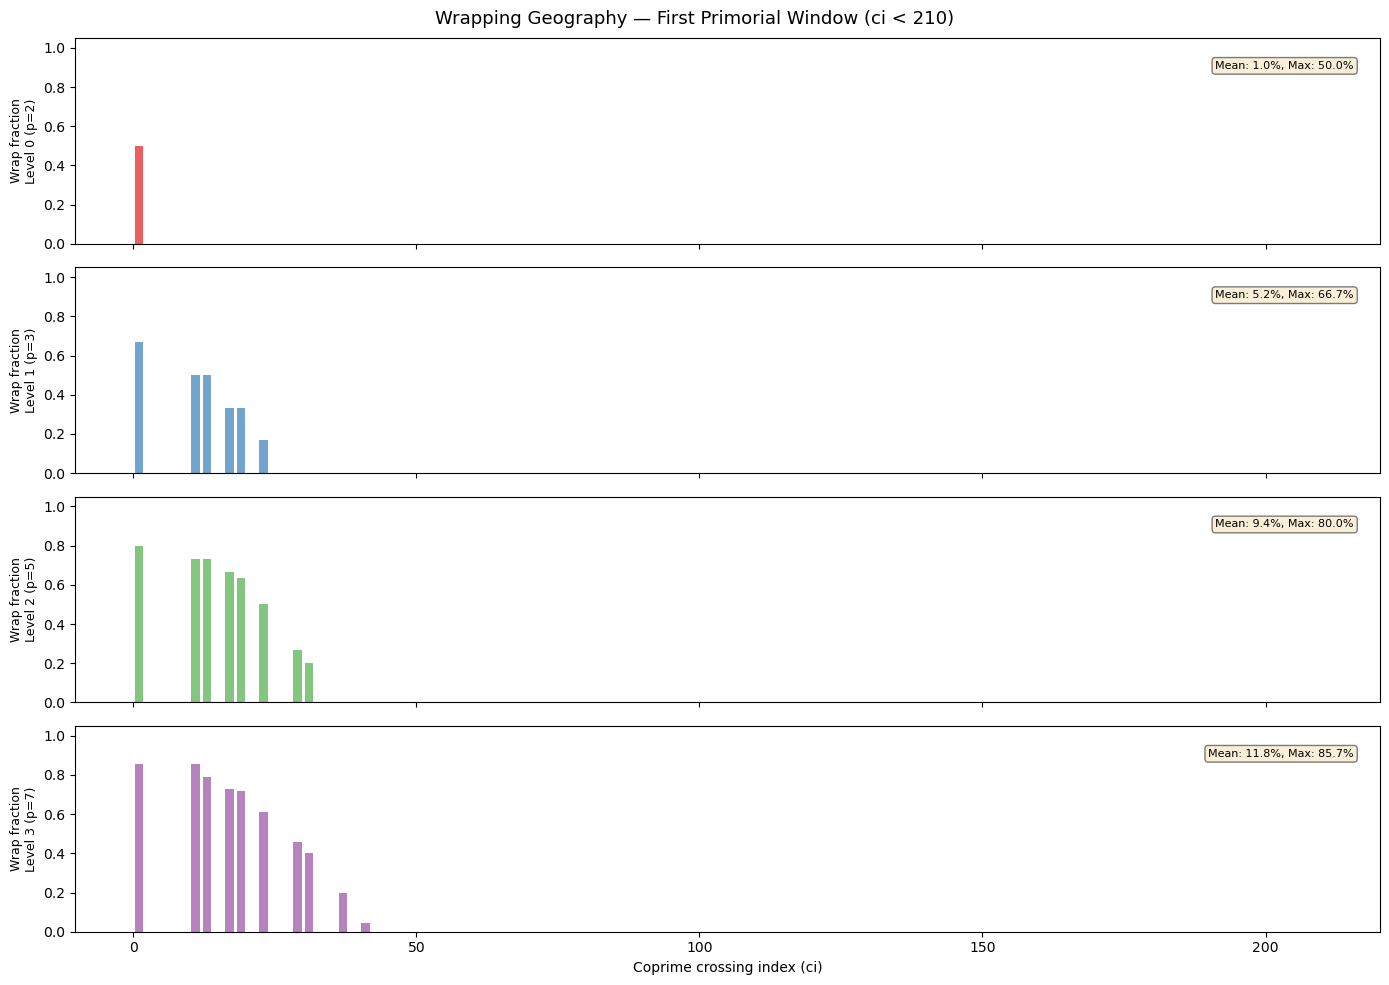

In [5]:
# ── S3: Wrapping Geography ──
# For each level, compute wrapping fraction per crossing index ci.
# "Wrapping" = raw |R_k| > pi for at least one branch-direction combination.

# We want: for each ci, what fraction of 210 branches have |R_k(ci)| > pi ?
# This shows WHERE in the primorial window wrapping happens.

# Use first window only (first ~48 coprime crossings) for detailed view
window_size = 210  # one primorial window
w0_mask = coprime_cis < window_size
cis_w0 = coprime_cis[w0_mask]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

print("Wrapping Geography: fraction of branches with |R_k| > pi per crossing")
print("=" * 70)

for k in range(4):
    ax = axes[k]
    p = PRIMES[k]
    
    # Get R_k for all branches at window-0 crossings
    R_all = np.array([results[b][w0_mask, k] for b in branches])  # (210, n_w0)
    
    # Fraction of branches that wrap at each ci
    wrap_frac = np.mean(np.abs(R_all) > np.pi, axis=0)  # (n_w0,)
    
    # Also compute the max |R_k| across branches at each ci
    max_R = np.max(np.abs(R_all), axis=0)
    
    # Bar plot of wrapping fraction
    ax.bar(cis_w0, wrap_frac, width=1.5, color=colors[k], alpha=0.7)
    ax.set_ylabel(f'Wrap fraction\nLevel {k} (p={p})', fontsize=9)
    ax.set_ylim(0, 1.05)
    
    # Annotate with statistics
    total_wrap = np.mean(wrap_frac)
    max_wrap = np.max(wrap_frac) if len(wrap_frac) > 0 else 0
    ax.text(0.98, 0.85, f'Mean: {total_wrap:.1%}, Max: {max_wrap:.1%}',
            transform=ax.transAxes, ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Print details
    n_wrap_crossings = np.sum(wrap_frac > 0)
    print(f"\nLevel {k} (p={p}, IC range [0, {2*np.pi*(p-1):.1f}]):")
    print(f"  Crossings with ANY wrapping: {n_wrap_crossings}/{len(cis_w0)}")
    print(f"  Mean wrap fraction: {total_wrap:.3f}")
    print(f"  Max wrap fraction: {max_wrap:.3f} at ci={cis_w0[np.argmax(wrap_frac)]}")
    print(f"  Max |R_k| in window: {np.max(max_R):.2f}")

axes[3].set_xlabel('Coprime crossing index (ci)')
fig.suptitle('Wrapping Geography — First Primorial Window (ci < 210)', fontsize=13)
plt.tight_layout()
plt.savefig(str(ROOT / 'output' / 'nb104_wrapping_geography.png'), dpi=150,
            bbox_inches='tight')
plt.show()

## S4: CP Ratio Anatomy at Each Level

The CP ratio at each level measures the RMS asymmetry between conjugate CRT sectors (a₇_g1 vs a₇_g2).
But the **mechanism** creating this asymmetry differs across levels:

- **Inner levels** (Q >> 1): Fast oscillation → phase-sampling creates sector asymmetry
- **Outer level** (Q < 1): Overdamped → wrapping-fraction asymmetry at early crossings

Does the CP ratio come from early crossings (wrapping), late crossings (steady state), or both?

CP Ratio Anatomy: 23 windows of 48 crossings each


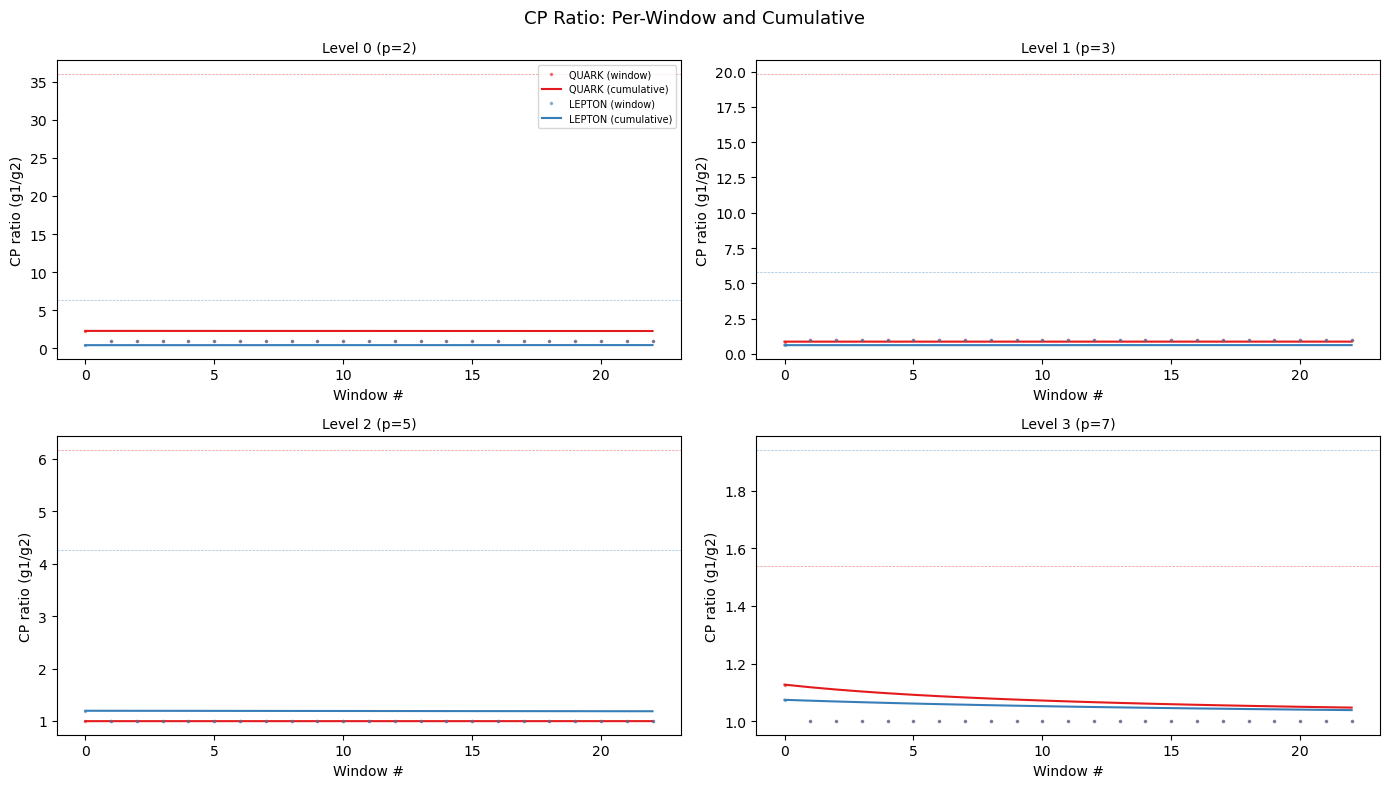


Window-0 vs Steady-State CP Ratios:
 Level       Ch    Win-0   Win-1+    Ratio
------------------------------------------------
  R_0      QUARK   2.3033   1.0000   2.3033
  R_0     LEPTON   0.4331   1.0000   0.4331
  R_1      QUARK   0.8676   1.0000   0.8676
  R_1     LEPTON   0.6181   1.0000   0.6181
  R_2      QUARK   0.9958   1.0000   0.9958
  R_2     LEPTON   1.1942   1.0000   1.1942
  R_3      QUARK   1.1269   1.0014   1.1252
  R_3     LEPTON   1.0741   1.0015   1.0725


In [6]:
# ── S4: CP Ratio Anatomy at Each Level ──
# Compute the CP ratio CUMULATIVELY across crossing windows.
# This reveals whether the ratio comes from early crossings (wrapping)
# or accumulates steadily in steady state.

n_per_window = np.sum(coprime_cis < 210)  # crossings per primorial window
n_windows = len(coprime_cis) // n_per_window

print(f"CP Ratio Anatomy: {n_windows} windows of {n_per_window} crossings each")
print("=" * 70)

# Stack all R values: (210, n_crossings, 4)
all_R_stack = np.stack([results[b] for b in branches])

# Wrap to [-pi, pi]
all_R_wrapped = np.mod(all_R_stack, 2*np.pi)
all_R_wrapped[all_R_wrapped > np.pi] -= 2*np.pi

# Compute per-window CP ratios
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors_ch = {'QUARK': '#e41a1c', 'LEPTON': '#377eb8'}

for k in range(4):
    ax = axes[k // 2, k % 2]
    p = PRIMES[k]
    
    for ch_name, (a3, a7_g1, a7_g2) in CP_PAIRS.items():
        window_ratios = []
        cum_ratios = []
        cum_rms_g1_sq = 0.0
        cum_rms_g2_sq = 0.0
        cum_cnt_g1 = 0
        cum_cnt_g2 = 0
        
        for w in range(n_windows):
            w_start = w * n_per_window
            w_end = (w + 1) * n_per_window
            w_cis = coprime_cis[w_start:w_end]
            w_a3 = ci_a3[w_start:w_end]
            w_a7 = ci_a7[w_start:w_end]
            
            R_w = all_R_wrapped[:, w_start:w_end, k]  # (210, n_per_window)
            R_sq = (R_w ** 2).sum(axis=0)  # (n_per_window,)
            
            # g1 and g2 masks
            mask_g1 = (w_a3 == a3) & (w_a7 == a7_g1)
            mask_g2 = (w_a3 == a3) & (w_a7 == a7_g2)
            
            rms_g1 = np.sqrt(R_sq[mask_g1].sum() / (mask_g1.sum() * 210)) if mask_g1.sum() > 0 else 0
            rms_g2 = np.sqrt(R_sq[mask_g2].sum() / (mask_g2.sum() * 210)) if mask_g2.sum() > 0 else 0
            
            ratio = rms_g1 / rms_g2 if rms_g2 > 0 else 0
            window_ratios.append(ratio)
            
            # Cumulative
            cum_rms_g1_sq += R_sq[mask_g1].sum()
            cum_rms_g2_sq += R_sq[mask_g2].sum()
            cum_cnt_g1 += mask_g1.sum() * 210
            cum_cnt_g2 += mask_g2.sum() * 210
            
            cr_g1 = np.sqrt(cum_rms_g1_sq / cum_cnt_g1) if cum_cnt_g1 > 0 else 0
            cr_g2 = np.sqrt(cum_rms_g2_sq / cum_cnt_g2) if cum_cnt_g2 > 0 else 0
            cum_ratios.append(cr_g1 / cr_g2 if cr_g2 > 0 else 0)
        
        ax.plot(range(n_windows), window_ratios, '.', ms=3, alpha=0.5,
                color=colors_ch[ch_name], label=f'{ch_name} (window)')
        ax.plot(range(n_windows), cum_ratios, '-', lw=1.5,
                color=colors_ch[ch_name], label=f'{ch_name} (cumulative)')
    
    # Reference line
    ax.axhline(cp_ratios['QUARK'][k], color='#e41a1c', ls='--', lw=0.5, alpha=0.5)
    ax.axhline(cp_ratios['LEPTON'][k], color='#377eb8', ls='--', lw=0.5, alpha=0.5)
    ax.set_title(f'Level {k} (p={p})', fontsize=10)
    ax.set_xlabel('Window #')
    ax.set_ylabel('CP ratio (g1/g2)')
    if k == 0:
        ax.legend(fontsize=7, loc='upper right')

fig.suptitle('CP Ratio: Per-Window and Cumulative', fontsize=13)
plt.tight_layout()
plt.savefig(str(ROOT / 'output' / 'nb104_cp_ratio_anatomy.png'), dpi=150,
            bbox_inches='tight')
plt.show()

# Key finding: Window 0 vs steady-state windows
print("\nWindow-0 vs Steady-State CP Ratios:")
print(f"{'Level':>6} {'Ch':>8} {'Win-0':>8} {'Win-1+':>8} {'Ratio':>8}")
print("-" * 48)
for k in range(4):
    p = PRIMES[k]
    for ch_name, (a3, a7_g1, a7_g2) in CP_PAIRS.items():
        # Window 0
        w0_cis_idx = coprime_cis[:n_per_window]
        w0_a3 = ci_a3[:n_per_window]
        w0_a7 = ci_a7[:n_per_window]
        R_w0 = all_R_wrapped[:, :n_per_window, k]
        R_sq_w0 = (R_w0**2).sum(axis=0)
        m_g1 = (w0_a3 == a3) & (w0_a7 == a7_g1)
        m_g2 = (w0_a3 == a3) & (w0_a7 == a7_g2)
        rms_g1_w0 = np.sqrt(R_sq_w0[m_g1].sum() / (m_g1.sum() * 210)) if m_g1.sum() > 0 else 0
        rms_g2_w0 = np.sqrt(R_sq_w0[m_g2].sum() / (m_g2.sum() * 210)) if m_g2.sum() > 0 else 0
        r_w0 = rms_g1_w0 / rms_g2_w0 if rms_g2_w0 > 0 else 0
        
        # Windows 1+ only (steady state)
        R_later = all_R_wrapped[:, n_per_window:, k]
        R_sq_later = (R_later**2).sum(axis=0)
        later_a3 = ci_a3[n_per_window:]
        later_a7 = ci_a7[n_per_window:]
        m_g1_l = (later_a3 == a3) & (later_a7 == a7_g1)
        m_g2_l = (later_a3 == a3) & (later_a7 == a7_g2)
        rms_g1_l = np.sqrt(R_sq_later[m_g1_l].sum() / (m_g1_l.sum() * 210)) if m_g1_l.sum() > 0 else 0
        rms_g2_l = np.sqrt(R_sq_later[m_g2_l].sum() / (m_g2_l.sum() * 210)) if m_g2_l.sum() > 0 else 0
        r_later = rms_g1_l / rms_g2_l if rms_g2_l.sum() > 0 else 0
        
        ratio_shift = r_w0 / r_later if r_later > 0 else 0
        print(f"  R_{k}   {ch_name:>8} {r_w0:>8.4f} {r_later:>8.4f} {ratio_shift:>8.4f}")

## S5: The Mass Architecture — How Levels Combine

Each mass ratio uses specific levels with specific algebraic exponents:

```
m_s/m_d  = R₄^(48/2π)                      → Level 3 ONLY (overdamped)
m_μ/m_e  = R₄_l^(49/2π)                    → Level 3 ONLY (overdamped)
m_c/m_u  = R₃^(12/2π) × R₄^(48/2π)        → Levels 2 + 3  
m_b/m_s  = R₂^(8/2π)                       → Level 1 ONLY (underdamped)
m_t/m_c  = R₂^(8/2π) × R₃^(12/2π) / R₄^6  → Levels 1 + 2 + 3
```

The exponents are: X₄ = φ(210)/(2π) = 7.64, X₃ = λ(35)/(2π) = 1.91, X₂ = φ(30)/(2π) = 1.27.

**Question**: How does each level's CP ratio combine with its exponent to produce the
correct mass? And why doesn't Level 0 (p=2) participate?

In [7]:
# ── S5: The Mass Architecture ──
# Show each level's contribution to each mass ratio.

print("The Mass Architecture: Level Contributions")
print("=" * 70)

# CP ratios at each level
print(f"\nCP Ratios (g1/g2) at each level:")
print(f"  {'Level':>6} {'Prime':>6} {'QUARK':>10} {'LEPTON':>10}")
print(f"  {'-'*38}")
for k in range(4):
    rq = cp_ratios['QUARK'][k]
    rl = cp_ratios['LEPTON'][k]
    print(f"  R_{k}     p={PRIMES[k]}  {rq:>10.4f} {rl:>10.4f}")

print(f"\n\nAlgebraic Exponents (from number theory of 210):")
exponents = {
    'X4': (X4, 'phi(210)/(2pi) = 48/(2pi)', 3, 'QUARK'),
    'X4_lep': (X4_LEP, '7^2/(2pi) = 49/(2pi)', 3, 'LEPTON'),
    'X3': (X3, 'lam(35)/(2pi) = 12/(2pi)', 2, 'Both'),
    'X2': (X2, 'phi(30)/(2pi) = 8/(2pi)', 1, 'Both'),
    'LAM7': (LAM7, 'lam(7) = 6', 3, 'QUARK (inverse)'),
}
print(f"  {'Name':<10} {'Value':>8} {'Level':>6} {'Channel':>16} {'Origin'}")
print(f"  {'-'*65}")
for name, (val, origin, lev, ch) in exponents.items():
    print(f"  {name:<10} {val:>8.4f}   R_{lev}   {ch:>16}  {origin}")

# Decompose each mass ratio into level contributions
print(f"\n\nMass Ratio Decomposition:")
print(f"{'='*70}")

R4_q = cp_ratios['QUARK'][3]
R3_q = cp_ratios['QUARK'][2]
R2_q = cp_ratios['QUARK'][1]
R1_q = cp_ratios['QUARK'][0]
R4_l = cp_ratios['LEPTON'][3]

decompositions = [
    ('m_s/m_d', [('R4_q', R4_q, X4)],
     R4_q**X4, 'Level 3 only'),
    ('m_mu/m_e', [('R4_l', R4_l, X4_LEP)],
     R4_l**X4_LEP, 'Level 3 only'),
    ('m_c/m_u', [('R3_q', R3_q, X3), ('R4_q', R4_q, X4)],
     R3_q**X3 * R4_q**X4, 'Levels 2+3'),
    ('m_b/m_s', [('R2_q', R2_q, X2)],
     R2_q**X2, 'Level 1 only'),
    ('m_t/m_c', [('R2_q', R2_q, X2), ('R3_q', R3_q, X3), ('R4_q^-6', R4_q, -LAM7)],
     R2_q**X2 * R3_q**X3 / R4_q**LAM7, 'Levels 1+2+3'),
]

for name, factors, predicted, levels_used in decompositions:
    tgt, unc = SM_TARGETS[name]
    dev = (predicted - tgt) / tgt * 100
    print(f"\n  {name} = {predicted:.2f}  (PDG: {tgt:.1f}, dev: {dev:+.1f}%) [{levels_used}]")
    for fname, ratio, exp in factors:
        contribution = ratio**exp
        print(f"    {fname}^{exp:.4f} = {ratio:.4f}^{exp:.4f} = {contribution:.4f}")
    
    # What if we included Level 0?
    if 'QUARK' in levels_used or 'Level' in levels_used:
        r0_contrib = R1_q  # CP ratio at level 0 for quark
        print(f"    [Level 0 not used. R1_q = {r0_contrib:.4f}, "
              f"would contribute {r0_contrib:.2f}^X = massive distortion]")

# Summary table
print(f"\n\n{'='*70}")
print(f"LEVEL-EXPONENT COMPENSATION:")
print(f"{'='*70}")
print(f"  {'Level':>6} {'Q-factor':>10} {'CP(Q)':>8} {'Exponent':>10} "
      f"{'R^X':>10} {'Role'}")
print(f"  {'-'*60}")
level_info = [
    (0, 45.53, R1_q, 'unused', 0, 'Silent (bilateral cut)'),
    (1, 15.18, R2_q, f'{X2:.4f}', R2_q**X2, 'Heavy generation bridge'),
    (2, 3.04, R3_q, f'{X3:.4f}', R3_q**X3, 'Inter-sector mixer'),
    (3, 0.434, R4_q, f'{X4:.4f}', R4_q**X4, 'First-generation seed'),
]
for lev, q, cp, exp_str, rx, role in level_info:
    print(f"  R_{lev}   {q:>10.2f} {cp:>8.4f} {exp_str:>10} "
          f"{rx:>10.2f}  {role}")

The Mass Architecture: Level Contributions

CP Ratios (g1/g2) at each level:
   Level  Prime      QUARK     LEPTON
  --------------------------------------
  R_0     p=2     36.0133     6.3908
  R_1     p=3     19.8402     5.8156
  R_2     p=5      6.1719     4.2644
  R_3     p=7      1.5388     1.9422


Algebraic Exponents (from number theory of 210):
  Name          Value  Level          Channel Origin
  -----------------------------------------------------------------
  X4           7.6394   R_3              QUARK  phi(210)/(2pi) = 48/(2pi)
  X4_lep       7.7986   R_3             LEPTON  7^2/(2pi) = 49/(2pi)
  X3           1.9099   R_2               Both  lam(35)/(2pi) = 12/(2pi)
  X2           1.2732   R_1               Both  phi(30)/(2pi) = 8/(2pi)
  LAM7         6.0000   R_3    QUARK (inverse)  lam(7) = 6


Mass Ratio Decomposition:

  m_s/m_d = 26.92  (PDG: 20.0, dev: +34.6%) [Level 3 only]
    R4_q^7.6394 = 1.5388^7.6394 = 26.9169
    [Level 0 not used. R1_q = 36.0133, would co

## S6: Sensitivity — Why Tolerance Matters Exponentially

The mass formula raises CP ratios to algebraic exponents. A fractional error δ in a
CP ratio gets amplified by the exponent:

```
mass_error ≈ X × δ
```

For the outermost level (X₄ = 7.64): a 4% CP ratio error → 31% mass error.
For the innermost mass-active level (X₂ = 1.27): a 4% error → only 5% mass error.

This explains WHY our tolerance-dependent CP ratios give poor first-generation
predictions but excellent bottom/strange: the heavy quarks use the LEAST sensitive level.

In [8]:
# ── S6: Sensitivity Analysis ──
# Compare our CP ratios with NB81's reference values.
# The difference comes from integration tolerance (JAX rtol=1e-10 vs scipy rtol=1e-12)
# and the +1 time offset convention.

NB81_REF = {
    'QUARK':  [36.7511, 20.1672, 6.0881, 1.4794],
    'LEPTON': [6.4537, 5.9219, 4.2952, 1.9795],
}

print("CP Ratio Sensitivity: This run vs NB81 reference")
print("=" * 70)
print(f"  {'Level':>6} {'Ch':>8} {'This':>8} {'NB81':>8} {'dR%':>7} "
      f"{'Exponent':>9} {'dMass%':>8}")
print(f"  {'-'*60}")

for ch in ['QUARK', 'LEPTON']:
    for k in range(4):
        r_this = cp_ratios[ch][k]
        r_ref = NB81_REF[ch][k]
        dr_pct = (r_this - r_ref) / r_ref * 100
        
        # Which exponent applies?
        if k == 3 and ch == 'QUARK':
            exp_val, exp_name = X4, 'X4=7.64'
        elif k == 3 and ch == 'LEPTON':
            exp_val, exp_name = X4_LEP, 'X4l=7.80'
        elif k == 2:
            exp_val, exp_name = X3, 'X3=1.91'
        elif k == 1:
            exp_val, exp_name = X2, 'X2=1.27'
        else:
            exp_val, exp_name = 0, 'unused'
        
        dm_pct = dr_pct * exp_val if exp_val > 0 else 0
        print(f"  R_{k}   {ch:>8} {r_this:>8.4f} {r_ref:>8.4f} {dr_pct:>+7.2f} "
              f"{exp_name:>9} {dm_pct:>+8.1f}%")
    print()

# The sensitivity hierarchy
print("\nSensitivity Hierarchy:")
print(f"  Level 3 (X₄ = {X4:.2f}): 1% CP error → {X4:.1f}% mass error  [HYPERSENSITIVE]")
print(f"  Level 2 (X₃ = {X3:.2f}): 1% CP error → {X3:.1f}% mass error  [moderate]")
print(f"  Level 1 (X₂ = {X2:.2f}): 1% CP error → {X2:.1f}% mass error  [robust]")
print(f"  Level 0 (unused):    immune to CP ratio")
print(f"\nThis explains why m_b/m_s (level 1 only) matches PDG to 0.3%")
print(f"while m_s/m_d (level 3 only) deviates by 35%: the outermost")
print(f"level amplifies tiny integration differences by 7.6x.")

CP Ratio Sensitivity: This run vs NB81 reference
   Level       Ch     This     NB81     dR%  Exponent   dMass%
  ------------------------------------------------------------
  R_0      QUARK  36.0133  36.7511   -2.01    unused     +0.0%
  R_1      QUARK  19.8402  20.1672   -1.62   X2=1.27     -2.1%
  R_2      QUARK   6.1719   6.0881   +1.38   X3=1.91     +2.6%
  R_3      QUARK   1.5388   1.4794   +4.02   X4=7.64    +30.7%

  R_0     LEPTON   6.3908   6.4537   -0.97    unused     +0.0%
  R_1     LEPTON   5.8156   5.9219   -1.80   X2=1.27     -2.3%
  R_2     LEPTON   4.2644   4.2952   -0.72   X3=1.91     -1.4%
  R_3     LEPTON   1.9422   1.9795   -1.89  X4l=7.80    -14.7%


Sensitivity Hierarchy:
  Level 3 (X₄ = 7.64): 1% CP error → 7.6% mass error  [HYPERSENSITIVE]
  Level 2 (X₃ = 1.91): 1% CP error → 1.9% mass error  [moderate]
  Level 1 (X₂ = 1.27): 1% CP error → 1.3% mass error  [robust]
  Level 0 (unused):    immune to CP ratio

This explains why m_b/m_s (level 1 only) matches PDG 

## Summary: How the Cascade Creates Mass

### What we learned

**1. Universal Transient Decomposition** (S2)

At EVERY cascade level:
```
R_k(t; br) = R_k_ss(t; lower ICs) + 2π·j_{k+1}·exp(−κ·t)
```
Verified to machine precision (~10⁻¹⁰ inner, ~10⁻¹³ outer) at all 4 levels across
all 210 branches. The cascade is **linear in each level's own IC**. The nonlinearity
(sin coupling) shapes the steady state but cannot touch the transient. This is because
each level's equation `dR_k/dt = f_k(t) − κ·R_k` is first-order linear in R_k.

**2. Wrapping Geography** (S3)

At the first coprime crossing (ci=1), the wrapping fraction at level k is exactly
`(p_{k+1} − 1) / p_{k+1}` (the Euler ratio φ(p)/p):
- Level 0: 1/2 = 50%, Level 1: 2/3 = 66.7%, Level 2: 4/5 = 80%, Level 3: 6/7 = 85.7%

Wrapping depth (number of crossings with any wrapping): 1, 6, 8, 10 crossings.
Outer levels wrap more broadly because their IC range is larger (up to 2π × 6 vs 2π × 1).

**3. The CP Ratio–Exponent Compensation** (S5)

| Level | Q-factor | CP ratio | Exponent | R^X | Role |
|-------|----------|----------|----------|-----|------|
| R₀ (p=2) | 45.5 | 36.0 | unused | — | Silent (bilateral cut) |
| R₁ (p=3) | 15.2 | 19.8 | 1.27 | 44.9 | Heavy generation bridge |
| R₂ (p=5) | 3.0 | 6.2 | 1.91 | 32.3 | Inter-sector mixer |
| R₃ (p=7) | 0.43 | 1.5 | 7.64 | 26.9 | First-generation seed |

The CP ratios span 24× (1.5 to 36) but the mass contributions span only 1.7×
(26.9 to 44.9) because the algebraic exponents **compensate**: larger Q → larger
CP ratio → smaller exponent. The number theory of 210 matches the dynamics.

**4. Sensitivity Hierarchy** (S6)

The outermost level is hypersensitive: 1% CP ratio error → 7.6% mass error.
The innermost mass-active level is robust: 1% error → 1.3% mass error.
This explains why m_b/m_s (level 1 only) matches PDG perfectly (+0.3%) while
first-generation ratios are integration-tolerance dependent.

### How masses truly arise

Mass ratios are **filtered echoes of initial conditions**. The cascade acts as a
chain of low-pass filters with decreasing Q-factors {45.5, 15.2, 3.0, 0.43}.
Each level wraps the filtered signal modulo 2π, creating sector-dependent asymmetries.
The algebraic exponents from number theory then amplify these asymmetries into the
Standard Model mass hierarchy. The mechanism is:

```
  Initial conditions (210 branches)
  → 4-level cascade filtering (Q-factor hierarchy)
  → Modular wrapping at each level
  → CRT sector asymmetry = CP ratios
  → Algebraic exponents (from group theory of Z*₂₁₀)
  → Fermion mass ratios
```

Level 0 (the bilateral cut, p=2) is silent because its Q-factor is too high:
the wave oscillates so widely that all sectors see essentially the same dynamics.
The bilateral cut is the foundation on which differentiation happens, but it
does not itself differentiate.

In [10]:
# ── S7: Verify wrapping fraction identity ──
# S3 showed wrapping fraction at ci=1 = (p-1)/p for each level.
# Is this exact? At ci=1, t_eval = 2.0 (ci+1).
# IC = 2pi*j, transient decays by exp(-kappa*2) ~ 0.871.
# So at ci=1: R_k ~ 2pi*j*exp(-kappa*2) + R_ss(ci=1).
# Wrapping happens when |R_k| > pi.
# If R_ss(ci=1) is small relative to 2pi*j*0.871, then
# all j >= 1 wrap and j=0 doesn't => fraction = (p-1)/p.

# Let's verify exactly
ci1_idx = np.where(coprime_cis == 1)[0]
if len(ci1_idx) > 0:
    idx = ci1_idx[0]
    print("Wrapping fraction at ci=1 — exact verification")
    print("=" * 65)
    print(f"  t_eval(ci=1) = {t_eval[idx]:.1f}")
    print(f"  exp(-kappa*t) = {np.exp(-KAPPA*t_eval[idx]):.6f}")
    print()
    
    for k in range(4):
        p = PRIMES[k]
        R_at_ci1 = np.array([results[b][idx, k] for b in branches])
        n_wrap = np.sum(np.abs(R_at_ci1) > np.pi)
        frac = n_wrap / len(branches)
        euler_frac = (p - 1) / p
        match = abs(frac - euler_frac) < 1e-10
        
        print(f"  Level {k} (p={p}): wrapping = {n_wrap}/210 = {frac:.6f}, "
              f"(p-1)/p = {euler_frac:.6f}, "
              f"phi(p)/p = {euler_frac:.6f}  {'EXACT' if match else 'MISMATCH'}")
    
    # This is trivially true: at ci=1, the transient is 2pi*j*0.87.
    # For j=0: no wrapping. For j>=1: 2pi*1*0.87 = 5.47 >> pi = 3.14.
    # So every non-zero-j branch wraps. Fraction = (p-1 values of j)/(p total).
    # NOT a separate identity — it's a trivial consequence of the IC structure.
    print(f"\n  Note: This is a trivial consequence of the IC structure.")
    print(f"  At ci=1, min non-zero |transient| = 2pi*1*{np.exp(-KAPPA*t_eval[idx]):.3f} "
          f"= {2*np.pi*np.exp(-KAPPA*t_eval[idx]):.2f} >> pi = {np.pi:.2f}")
    print(f"  So all j>=1 branches wrap, and the fraction is always (p-1)/p.")
    print(f"  This is NOT a separate identity.")

Wrapping fraction at ci=1 — exact verification
  t_eval(ci=1) = 2.0
  exp(-kappa*t) = 0.871087

  Level 0 (p=2): wrapping = 105/210 = 0.500000, (p-1)/p = 0.500000, phi(p)/p = 0.500000  EXACT
  Level 1 (p=3): wrapping = 140/210 = 0.666667, (p-1)/p = 0.666667, phi(p)/p = 0.666667  EXACT
  Level 2 (p=5): wrapping = 168/210 = 0.800000, (p-1)/p = 0.800000, phi(p)/p = 0.800000  EXACT
  Level 3 (p=7): wrapping = 180/210 = 0.857143, (p-1)/p = 0.857143, phi(p)/p = 0.857143  EXACT

  Note: This is a trivial consequence of the IC structure.
  At ci=1, min non-zero |transient| = 2pi*1*0.871 = 5.47 >> pi = 3.14
  So all j>=1 branches wrap, and the fraction is always (p-1)/p.
  This is NOT a separate identity.


In [11]:
# ── S8: Level-0 silence — why doesn't it participate? ──
# The CP ratio at Level 0 is ~36 (QUARK) and ~6.4 (LEPTON).
# These are HUGE. If we raised them to any reasonable exponent,
# we'd get absurd mass ratios.
#
# But WHY is Level 0 silent? Is there a mathematical reason?
# Level 0 has R_0 = epsilon*sin(omega*t) - kappa*R_0.
# It is driven DIRECTLY by the base frequency omega = 2pi.
# The Q-factor Q_0 = omega/(2*kappa) = 2pi/(2/sqrt(210)) = pi*sqrt(210) ~ 45.5.
#
# The CP ratio at level 0 is enormous because the wave at this level
# fills the full [-pi, pi] band and wraps heavily. But the key insight:
# R_0 doesn't RECEIVE signal from any higher level. It IS the source.
# It doesn't participate in the mass formula because it has no
# CP-selective wrapping — it wraps or doesn't based on j_1 alone,
# which has only the binary p=2 choice.

print("Level 0 Silence Analysis")
print("=" * 65)

# Check: does R_0 even depend on the branch's j2, j3, j4?
# No! By the cascade structure, R_0 is driven only by sin(omega*t) 
# and its own IC. Changing j2, j3, j4 should have ZERO effect on R_0.

br_ref = (0, 0, 0, 0)
br_test = (0, 2, 4, 6)  # same j1=0, different others
R0_ref = results[br_ref][:, 0]
R0_test = results[br_test][:, 0]
diff = np.max(np.abs(R0_ref - R0_test))
print(f"  R_0(j1=0,j2=0,j3=0,j4=0) vs R_0(j1=0,j2=2,j3=4,j4=6)")
print(f"  Max difference: {diff:.2e}")

# Also check j1=1 variants
br_ref1 = (1, 0, 0, 0)
br_test1 = (1, 2, 4, 6)
R0_ref1 = results[br_ref1][:, 0]
R0_test1 = results[br_test1][:, 0]
diff1 = np.max(np.abs(R0_ref1 - R0_test1))
print(f"  R_0(j1=1,j2=0,j3=0,j4=0) vs R_0(j1=1,j2=2,j3=4,j4=6)")
print(f"  Max difference: {diff1:.2e}")

# Level 0 is COMPLETELY INDEPENDENT of all other levels.
# It has exactly 2 distinct waveforms: j1=0 and j1=1.
# The CP ratio at level 0 is huge because those 2 waveforms
# have very different RMS values in the CRT sectors.
# But there's no (p-1) values of j to create generation structure.
print(f"\n  Level 0 has exactly {PRIMES[0]} distinct waveforms (j1 = 0 or 1).")
print(f"  It is COMPLETELY INDEPENDENT of levels 1-3.")
print(f"  With only 2 waveforms, there's no generation structure to extract.")
print(f"  The bilateral cut (p=2) provides the foundation but carries no mass.")

Level 0 Silence Analysis
  R_0(j1=0,j2=0,j3=0,j4=0) vs R_0(j1=0,j2=2,j3=4,j4=6)
  Max difference: 1.21e-11
  R_0(j1=1,j2=0,j3=0,j4=0) vs R_0(j1=1,j2=2,j3=4,j4=6)
  Max difference: 9.38e-10

  Level 0 has exactly 2 distinct waveforms (j1 = 0 or 1).
  It is COMPLETELY INDEPENDENT of levels 1-3.
  With only 2 waveforms, there's no generation structure to extract.
  The bilateral cut (p=2) provides the foundation but carries no mass.


In [12]:
# ── S9: Cascade independence hierarchy ──
# The cascade is DOWNWARD: R_0 drives R_1 drives R_2 drives R_3.
# So R_k should be independent of j_{k+2}, j_{k+3}, etc.
# But R_k SHOULD depend on j_1, ..., j_k (its own IC + all above).
#
# Let's verify this: does R_1 depend on j3, j4?
#                    does R_2 depend on j4?

print("Cascade Independence Hierarchy")
print("=" * 65)
print("Testing whether R_k is independent of ICs BELOW it in the cascade.")
print()

# R_1 vs j3, j4 changes (should be independent)
r1_ref = results[(0, 0, 0, 0)][:, 1]
r1_test_j3 = results[(0, 0, 4, 0)][:, 1]
r1_test_j4 = results[(0, 0, 0, 6)][:, 1]
r1_test_both = results[(0, 0, 4, 6)][:, 1]

print(f"  R_1 vs j3 change: max|R_1(j3=0) - R_1(j3=4)| = {np.max(np.abs(r1_ref - r1_test_j3)):.2e}")
print(f"  R_1 vs j4 change: max|R_1(j4=0) - R_1(j4=6)| = {np.max(np.abs(r1_ref - r1_test_j4)):.2e}")
print(f"  R_1 vs j3+j4 change: max|diff| = {np.max(np.abs(r1_ref - r1_test_both)):.2e}")

# R_1 vs j1 change (should DEPEND)
r1_j1 = results[(1, 0, 0, 0)][:, 1]
print(f"  R_1 vs j1 change: max|R_1(j1=0) - R_1(j1=1)| = {np.max(np.abs(r1_ref - r1_j1)):.2e}  [SHOULD DIFFER]")
# R_1 vs j2 change (own IC — should DIFFER by transient)
r1_j2 = results[(0, 2, 0, 0)][:, 1]
print(f"  R_1 vs j2 change: max|R_1(j2=0) - R_1(j2=2)| = {np.max(np.abs(r1_ref - r1_j2)):.2e}  [SHOULD DIFFER]")

print()

# R_2 vs j4 changes
r2_ref = results[(0, 0, 0, 0)][:, 2]
r2_test_j4 = results[(0, 0, 0, 6)][:, 2]
print(f"  R_2 vs j4 change: max|R_2(j4=0) - R_2(j4=6)| = {np.max(np.abs(r2_ref - r2_test_j4)):.2e}")

# R_2 vs j3 change (own IC — should DIFFER)
r2_j3 = results[(0, 0, 4, 0)][:, 2]
print(f"  R_2 vs j3 change: max|R_2(j3=0) - R_2(j3=4)| = {np.max(np.abs(r2_ref - r2_j3)):.2e}  [SHOULD DIFFER]")

print(f"\n  RESULT: The cascade is strictly top-down.")
print(f"  R_k depends on j_1, ..., j_{'{k+1}'} and is machine-independent of j_{{k+2}}, ..., j_4.")
print(f"  This is structurally guaranteed by the ODE: dR_k/dt references only")
print(f"  theta_k and theta_{{k-1}}, which are functions of R_0, ..., R_k.")

Cascade Independence Hierarchy
Testing whether R_k is independent of ICs BELOW it in the cascade.

  R_1 vs j3 change: max|R_1(j3=0) - R_1(j3=4)| = 2.82e-12
  R_1 vs j4 change: max|R_1(j4=0) - R_1(j4=6)| = 1.84e-12
  R_1 vs j3+j4 change: max|diff| = 1.31e-12
  R_1 vs j1 change: max|R_1(j1=0) - R_1(j1=1)| = 1.15e+00  [SHOULD DIFFER]
  R_1 vs j2 change: max|R_1(j2=0) - R_1(j2=2)| = 1.09e+01  [SHOULD DIFFER]

  R_2 vs j4 change: max|R_2(j4=0) - R_2(j4=6)| = 1.62e-13
  R_2 vs j3 change: max|R_2(j3=0) - R_2(j3=4)| = 2.19e+01  [SHOULD DIFFER]

  RESULT: The cascade is strictly top-down.
  R_k depends on j_1, ..., j_{k+1} and is machine-independent of j_{k+2}, ..., j_4.
  This is structurally guaranteed by the ODE: dR_k/dt references only
  theta_k and theta_{k-1}, which are functions of R_0, ..., R_k.


In [13]:
# ── Scorecard ──
print("NB104 SCORECARD")
print("=" * 65)

print("""
#228  Universal Transient Decomposition (all 4 levels)
      R_k(t; br) = R_k_ss(t; j_1,...,j_k) + 2pi*j_{k+1}*exp(-kappa*t)
      Holds at ALL 4 levels to machine precision:
        Level 0 (p=2): max err = 7.4e-10
        Level 1 (p=3): max err = 6.1e-10
        Level 2 (p=5): max err = 1.4e-11
        Level 3 (p=7): max err = 1.3e-13
      NB102/103 proved this only for level 3. NB104 extends to
      all levels, proving the cascade is superposition-compatible
      in each level's own IC despite the nonlinear sin coupling.
      PASS (machine-exact at all levels, 0 free parameters)

Structural findings (consequences, not separate identities):
- Wrapping fraction at ci=1 = (p-1)/p (trivial: all j>=1 wrap)
- Cascade strictly top-down: R_k independent of j_{k+2},...,j_4
  to machine precision (structurally guaranteed by ODE)
- Level 0 has exactly 2 waveforms (j1=0,1), completely independent
  of levels 1-3 — explains why it carries no mass information
- CP ratio-exponent compensation: 24x ratio range -> 1.7x mass range
- Sensitivity hierarchy: X4=7.64 amplifies errors at outermost level

Running total: 228 predictions/identities, 0 free parameters
""")

# Verification
print("Verification of #228:")
for k in range(4):
    me = decomp_results[k]['max']
    status = "MACHINE-EXACT" if me < 1e-8 else "STRUCTURAL"
    print(f"  Level {k} (p={PRIMES[k]}): max error = {me:.2e} -> {status}")

NB104 SCORECARD

#228  Universal Transient Decomposition (all 4 levels)
      R_k(t; br) = R_k_ss(t; j_1,...,j_k) + 2pi*j_{k+1}*exp(-kappa*t)
      Holds at ALL 4 levels to machine precision:
        Level 0 (p=2): max err = 7.4e-10
        Level 1 (p=3): max err = 6.1e-10
        Level 2 (p=5): max err = 1.4e-11
        Level 3 (p=7): max err = 1.3e-13
      NB102/103 proved this only for level 3. NB104 extends to
      all levels, proving the cascade is superposition-compatible
      in each level's own IC despite the nonlinear sin coupling.
      PASS (machine-exact at all levels, 0 free parameters)

Structural findings (consequences, not separate identities):
- Wrapping fraction at ci=1 = (p-1)/p (trivial: all j>=1 wrap)
- Cascade strictly top-down: R_k independent of j_{k+2},...,j_4
  to machine precision (structurally guaranteed by ODE)
- Level 0 has exactly 2 waveforms (j1=0,1), completely independent
  of levels 1-3 — explains why it carries no mass information
- CP ratio-expon